In [1]:
#importing necessary modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import  LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_csv("/content/car_price_prediction.csv")

#**Data Cleaning**

In [3]:
print("Missing values before cleaning:")
df.isnull().sum()

Missing values before cleaning:


,0
ID,0
Price,0
Levy,0
Manufacturer,0
Model,0
Prod. year,0
Category,0
Leather interior,0
Fuel type,0
Engine volume,0


In [5]:
print("Duplicate rows before cleaning:")
df.duplicated().sum()

Duplicate rows before cleaning:


np.int64(313)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [11]:
df['Levy'] = pd.to_numeric(df['Levy'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              13418 non-null  float64
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [12]:
#missing values in  levy after conversion
missing_vals = df['Levy'].isnull().sum()
print(missing_vals)

5819


In [14]:
#filling missing vals in levy
df['Levy'] = df['Levy'].fillna(df['Levy'].mean())
print(df['Levy'].isnull().sum())

0


#**Label Encoding**

In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print("DataFrame after Label Encoding:")
df.head()

DataFrame after Label Encoding:


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399.000000,32,1242,2010,4,1,2,63,2838,6.0,0,0,1,0,12,12
1,44731507,16621,1018.000000,8,658,2011,4,0,5,56,2960,6.0,2,0,1,0,1,8
2,45774419,8467,906.838128,21,684,2006,3,0,5,22,3140,4.0,3,1,1,1,1,2
3,45769185,3607,862.000000,16,661,2011,4,1,2,46,2413,4.0,0,0,1,0,14,0
4,45809263,11726,446.000000,21,684,2014,3,1,5,22,7396,4.0,0,1,1,0,12,4


In [16]:
X = df.drop('Price', axis=1)
y = df['Price']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (19237, 17)
Shape of y: (19237,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (15389, 17)
Shape of X_test: (3848, 17)
Shape of y_train: (15389,)
Shape of y_test: (3848,)


In [18]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [19]:
#prediction block on dependent variable y
y_pred = model.predict(X_test)

In [21]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
n = X_test.shape[0] # Number of observations
p = X_test.shape[1] # Number of predictor variables
adjusted_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))

print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")


R-squared: -0.1629
Mean Squared Error (MSE): 362346352.3793
Mean Absolute Error (MAE): 13423.1267


In [22]:
#determininf if this model is generalized model, underfitting or overfitting
y_train_pred = model.predict(X_train)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

print("Train R2:", r2_train)
print("Test R2:", r2_test)
#this is underfitting- train r square is almost 0 and test r squaare is negative

Train R2: 0.0036103588930146424
Test R2: -0.16286999057692908


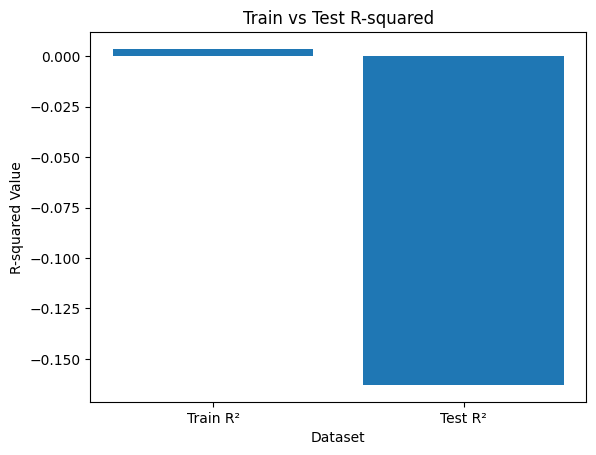

In [24]:
#visualizing the output
# Given R² values
train_r2 = 0.0036103588930146424
test_r2 = -0.16286999057692908
plt.figure()
plt.bar(['Train R²', 'Test R²'], [train_r2, test_r2])

plt.title('Train vs Test R-squared')
plt.xlabel('Dataset')
plt.ylabel('R-squared Value')

plt.show()
